In [2]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
import matplotlib.pyplot as plt

## Create first quantum circuit
---

This will consist of a single qubit.
- I'll first measure its value, and then I'll store the value of that measurement in a classical bit.
- Next I'll create a new variable named QR for our quantum register. And we'll pass it in input argument of one to indicate this register will store one qubit.

In [3]:
qr = QuantumRegister(1) # The input arg of 1 will is used to indicate this register will store one qubit.
cr = ClassicalRegister(1)
# Combine both registers into a quantum circuit.
circuit = QuantumCircuit(qr, cr)
## Using this circuit, I'll perform a measure operation on the quantum register and store the result
circuit.measure(qr, cr)

## QASM simulator backend
---
- The QASM simulator backend will simulate executing our quantum circuit and give back a Python dictionary object, containing a count of the measured outcomes of the classical registers.
- I'll capture that result in a new variable named result.
- Then call the execute function. Passing in the circuit. Setting the backend to the simulator.
- And then setting the number of shots to 1,024.
The execute function submits a job to the aer simulator.

---
##  Measuring Distribution
Qubits cannot be directly observe a superposition state. When measuring a qubit, we'll observe one of its two basis states.
```
shots = 1024
```
### Trade-off
there's a trade off to make between precision and execution time. The shots argument for the execute function, tells the simulator how many times to run the program. So, in this case, we'll gather 1024 outcomes to build our distribution allowing for a better understand the real probability distribution of that qubit in super position.

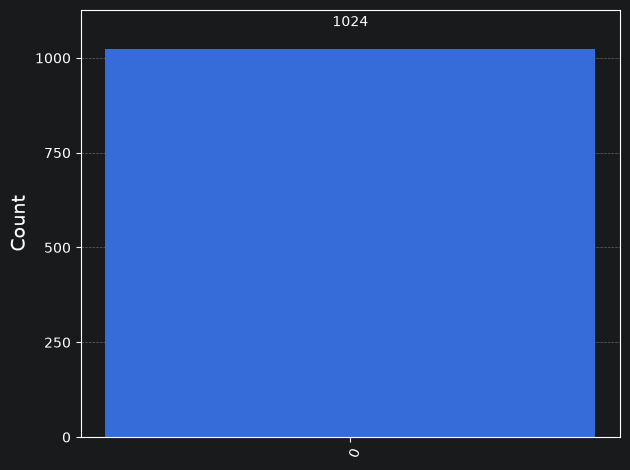

In [4]:
simulator = Aer.get_backend('qasm_simulator') #Quantum Assembly Language
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=1024).result()

plot_histogram(result.get_counts()) # View distribution.

## Results
---
The resulting histogram contains a single bar with a zero at the bottom, meaning the circuit measured a value of zero each shot.
Thus, the resulting probability for zero is 100% or 1.

## Analysis
---
When a new qubit is initialized, it always starts in the zero basis state.
Because no quantum operations have been applied, the qubits have not entered any superposition states.

## Adding an H-gate to the quantum register
---
This will put the qubit into a superposition giving it the probability to be measured as either one or zero.

In [8]:
qr = QuantumRegister(1) # The input arg of 1 will is used to indicate this register will store one qubit.
cr = ClassicalRegister(1)
# Combine both registers into a quantum circuit.
circuit = QuantumCircuit(qr, cr)
#Hadamard
circuit.h(0)
## Using this circuit, I'll perform a measure operation on the quantum register and store the result
circuit.measure(qr, cr)

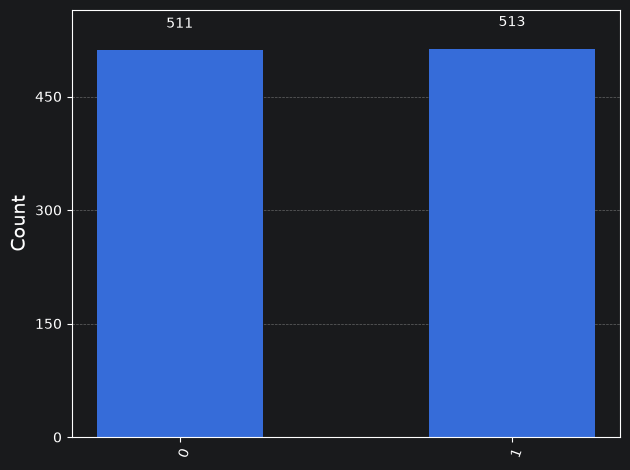

In [9]:
simulator = Aer.get_backend('qasm_simulator') #Quantum Assembly Language
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=1024).result()

plot_histogram(result.get_counts()) # View distribution.\

## Increasing the number of shots for a more precise distribution

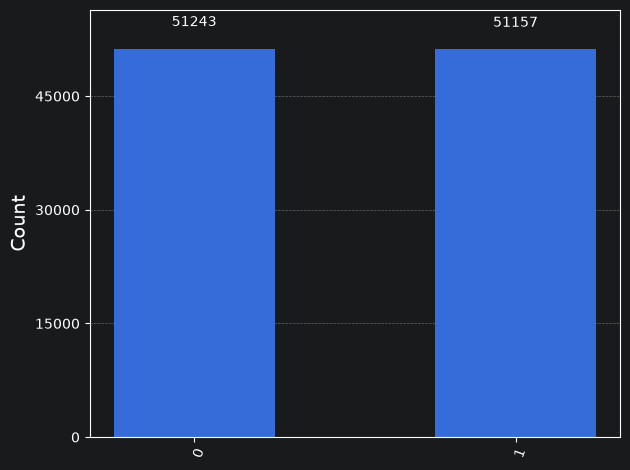

In [6]:
simulator = Aer.get_backend('qasm_simulator')  #Quantum Assembly Language
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=102400).result()

plot_histogram(result.get_counts())  # View distribution.\

## Analysis
---
The probability distribution is closer to a 50/50 split.

---
To view the actual number of outcomes, I will run:

In [32]:
print(result.get_counts())

{'0': 50985, '1': 51415}
